In [16]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
import xgboost as xgb

Data collection

In [2]:
data_dl = pd.read_csv(r'C:\Users\chaka\Preethu\My_Git_Repo\Final Project_Rideflow\Datasets\rideflow_datasets.csv')
data_dl.head()

,ride_id,timestamp,pickup_zone,drop_zone,pickup_lat,pickup_long,drop_lat,drop_long,driver_id,customer_id,...,surge_multiplier,driver_rating,customer_rating,estimated_eta_min,actual_eta_min,ride_status,traffic_level,weather,driver_active,feedback_text
0,95.247911,2025-01-02 01:30:00,Anna Nagar,Adyar,12.880239,80.148410,13.028939,80.163941,1842.701958,6072.494896,...,1.001779,4.350624,4.037232,11.778023,18.304775,cancelled,low,clear,-0.036560,Driver was polite
1,439.187632,2025-01-05 12:45:00,T Nagar,Tambaram,13.092441,80.165458,13.142711,80.149376,1186.296422,5942.228896,...,1.193147,4.524196,3.324278,4.430894,13.343961,completed,low,cloudy,0.988999,Driver cancelled suddenly
2,876.685389,2025-01-09 23:00:00,Anna Nagar,Tambaram,12.817965,80.161839,12.943527,80.166040,1297.199801,5829.181415,...,2.008478,4.054085,4.979153,19.202891,12.039878,completed,low,rain,0.005750,Driver cancelled suddenly
3,275.337197,2025-01-03 19:30:00,T Nagar,Velachery,13.125103,80.143306,13.209127,80.126008,1765.474261,5429.619496,...,1.218528,3.689937,3.099466,18.711931,7.535792,completed,low,clear,1.023604,Good experience
4,106.743950,2025-01-02 02:30:00,Tambaram,Tambaram,13.143513,80.302596,13.078330,80.189672,1565.653849,5079.081677,...,1.497370,3.545512,3.073704,10.786351,12.104096,completed,high,cloudy,1.016716,Vehicle was not clean


In [3]:
data_dl.columns

Index(['ride_id', 'timestamp', 'pickup_zone', 'drop_zone', 'pickup_lat',
       'pickup_long', 'drop_lat', 'drop_long', 'driver_id', 'customer_id',
       'fare_price', 'surge_multiplier', 'driver_rating', 'customer_rating',
       'estimated_eta_min', 'actual_eta_min', 'ride_status', 'traffic_level',
       'weather', 'driver_active', 'feedback_text'],
      dtype='object')

In [4]:
#sorting data by ride_id, timestamp to maintain temporal order for LSTM
data_dl = data_dl.sort_values(by=['timestamp']).reset_index(drop=True)

In [5]:
#preprocessing for LSTM
#fix data types
data_dl['driver_id'] = data_dl['driver_id'].astype(int)

#distance feature using geodesic distance
from geopy.distance import geodesic
data_dl['distance_km'] = data_dl.apply(lambda row: geodesic((row['pickup_lat'], row['pickup_long']), (row['drop_lat'], row['drop_long'])).km, axis=1)

#timestamp to datetime and extracting temporal features
data_dl['timestamp'] = pd.to_datetime(data_dl['timestamp'])
# Temporal Features
data_dl['hour'] = data_dl['timestamp'].dt.hour
data_dl['hour_sin'] = np.sin(2 * np.pi * data_dl['hour'] / 24)
data_dl['hour_cos'] = np.cos(2 * np.pi * data_dl['hour'] / 24)
    
# Ordinal Encoding for Traffic (Low:0, Medium:1, High:2)
data_dl['traffic_level'] = data_dl['traffic_level'].map({
    'low': 0,
    'medium': 1,
    'high': 2
})
    

In [6]:
#defining features and target variable
Features = data_dl[['hour','hour_sin', 'hour_cos', 'distance_km', 'traffic_level']]
Target = data_dl[['estimated_eta_min']]

In [7]:
Features.shape

(50000, 5)

In [8]:
#scaling features
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_scaled = scaler_X.fit_transform(Features)
y_scaled = scaler_y.fit_transform(Target)

In [9]:
#SEQUENCE CREATION (The "LSTM Step")
def create_sequences(X, y, time_steps):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:i+time_steps])
        ys.append(y[i+time_steps])
    return np.array(Xs), np.array(ys)

time_steps = 15
X_seq, y_seq = create_sequences(X_scaled, y_scaled, time_steps)

In [10]:
#train-test split_time based
split = int(0.8 * len(X_seq))

X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

c:\Users\chaka\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 22s 19ms/step - loss: 0.0853 - val_loss: 0.0812 - learning_rate: 0.0010
Epoch 2/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 19s 19ms/step - loss: 0.0786 - val_loss: 0.0809 - learning_rate: 0.0010
Epoch 3/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 27s 27ms/step - loss: 0.0767 - val_loss: 0.0816 - learning_rate: 0.0010
Epoch 4/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 35s 21ms/step - loss: 0.0757 - val_loss: 0.0810 - learning_rate: 0.0010
Epoch 5/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 23s 23ms/step - loss: 0.0750 - val_loss: 0.0807 - learning_rate: 0.0010
Epoch 6/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - loss: 0.0742 - val_loss: 0.0803 - learning_rate: 0.0010
Epoch 7/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 0.0735 - val_loss: 0.0812 - learning_rate: 0.0010
Epoch 8/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 22s 22ms/step - loss: 0.0728 - val_loss: 0.0833 - learning_rate: 0.0010
Epoch 9/30
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - loss: 0.0716 - val_loss: 0.082

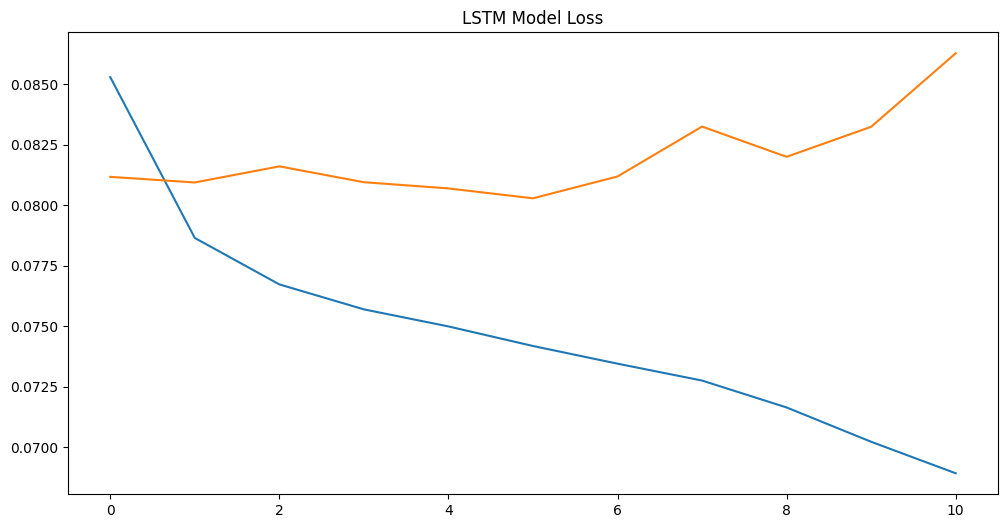

In [11]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau( monitor='val_loss', factor=0.5, patience=3, min_lr=0.001)
LSTM_model = Sequential([
    # Input shape: (seq_length, Features)
    LSTM(64, activation='tanh', input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=True),
    Dropout(0.2),
    LSTM(32, activation='tanh', return_sequences=True),
    Dropout(0.2),
    LSTM(16, activation='relu', return_sequences=False),
    Dropout(0.2),
    Dense(1) # Final ETA output
])
LSTM_model.compile(optimizer='adam', loss='mse')
history = LSTM_model.fit(X_train, y_train, epochs=30, batch_size=32, validation_split=0.2, verbose=1, callbacks=[early_stopping, lr_scheduler])
# Plotting training history
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Model Loss')

predictions_scaled = LSTM_model.predict(X_test)
predictions_actual = scaler_y.inverse_transform(predictions_scaled)

In [14]:
#accuracy evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(scaler_y.inverse_transform(y_test), predictions_actual)
mse = mean_squared_error(scaler_y.inverse_transform(y_test), predictions_actual)
r2 = r2_score(scaler_y.inverse_transform(y_test), predictions_actual)
rmse = np.sqrt(mse)
print(f'MAE: {mae}, MSE: {mse}, R2 Score: {r2}, RMSE: {rmse}')


MAE: 4.080092756638754, MSE: 22.638892907388417, R2 Score: -0.04481416408058547, RMSE: 4.758034563492411


In [15]:
#saving the model
LSTM_model.save(r'C:\Users\chaka\Preethu\My_Git_Repo\Final Project_Rideflow\saved_models\lstm_eta_prediction_model.keras')

In [ ]:
#XGboost for better prediction
#Data collected from already preprocessed csv
data_xgb = pd.read_csv(r'C:\Users\chaka\Preethu\My_Git_Repo\Final Project_Rideflow\Datasets\preprocessed_rideflow_datasets.csv')


In [20]:
data_xgb.columns

Index(['ride_id', 'driver_id', 'customer_id', 'fare_price', 'surge_multiplier',
       'driver_rating', 'customer_rating', 'estimated_eta_min',
       'actual_eta_min', 'ride_status', 'traffic_level', 'driver_active',
       'feedback_text', 'hour', 'day_of_week', 'is_weekend',
       'available_drivers', 'distance_km', 'cancellation_risk', 'is_peak_hour',
       'eta_diff', 'ride_count', 'pickup_zone_Adyar', 'pickup_zone_Anna Nagar',
       'pickup_zone_OMR', 'pickup_zone_Porur', 'pickup_zone_T Nagar',
       'pickup_zone_Tambaram', 'pickup_zone_Velachery', 'drop_zone_Adyar',
       'drop_zone_Anna Nagar', 'drop_zone_OMR', 'drop_zone_Porur',
       'drop_zone_T Nagar', 'drop_zone_Tambaram', 'drop_zone_Velachery',
       'weather_clear', 'weather_cloudy', 'weather_rain'],
      dtype='object')

In [25]:
#features selection
Features_xgb = ['hour', 'day_of_week', 'is_weekend', 'traffic_level', 'distance_km','pickup_zone_Adyar', 'pickup_zone_Anna Nagar',
       'pickup_zone_OMR', 'pickup_zone_Porur', 'pickup_zone_T Nagar',
       'pickup_zone_Tambaram', 'pickup_zone_Velachery', 'drop_zone_Adyar',
       'drop_zone_Anna Nagar', 'drop_zone_OMR', 'drop_zone_Porur',
       'drop_zone_T Nagar', 'drop_zone_Tambaram', 'drop_zone_Velachery',
       'weather_clear', 'weather_cloudy', 'weather_rain', 'is_peak_hour']

In [26]:
#data defining
X = data_xgb[Features_xgb]
y = data_xgb['estimated_eta_min']

In [27]:
#train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [28]:
XGB_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

XGB_model.fit(X_train, y_train)
y_pred_xgb = XGB_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred_xgb)
mse = mean_squared_error(y_test, y_pred_xgb)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_xgb)

print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"R2 Score: {r2}")

MAE: 1.6049157501749973
RMSE: 2.2076838352037655
R2 Score: 0.8006659416744466


In [29]:
#hyper parameter tuning for better accuracy
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [5, 6, 7],
    'learning_rate': [0.05, 0.1]
}

grid_search = GridSearchCV(
    estimator=xgb.XGBRegressor(random_state=42),
    param_grid=param_grid,
    scoring='r2',
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)



Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Parameters: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300}
Best Score: 0.8793228800083447


In [31]:
best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(X_test)

from sklearn.metrics import r2_score
print("Final R2:", r2_score(y_test, y_pred_best))

Final R2: 0.8892235217080224


In [32]:
from sklearn.model_selection import cross_val_score

# 5-Fold Cross Validation
cv_scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

print("Cross-Validation R2 Scores:", cv_scores)
print("Mean R2:", cv_scores.mean())

Cross-Validation R2 Scores: [0.88933408 0.88265341 0.88699497 0.88551677 0.8864274 ]
Mean R2: 0.886185325117707


In [34]:
#saving the best model
import pickle
best_model = best_model  
with open(r'C:\Users\chaka\Preethu\My_Git_Repo\Final Project_Rideflow\Saved_models\XGB_ETA_prediction.pkl', 'wb') as f:
    pickle.dump(best_model, f)

#summary

Model	Performance
LSTM	R² ≈ 0 (very poor) ❌
XGBoost	R² ≈ 0.889+ ✅

Reasons for LSTM DECLINE:
        1. No sequential Dependency
        2. Artificial Sequence Creation
        3. Weak Time Signal
        4. Small Dataset for Deep Learning and sequential
        5. Overfitting and under-learning

LSTM was explored to capture temporal dependencies in ETA prediction. 
However, the dataset lacked true sequential patterns, as each ride was independent and synthetic.
Artificial sequence creation did not provide meaningful temporal context, leading to poor performance.

XGBoost, being a tree-based ensemble model, effectively handled tabular features such as distance, traffic, and time. 
It captured non-linear relationships and interactions between features, resulting in significantly better accuracy.

Therefore, i preferred to XGBoost as the final model for ETA prediction.